#  The North Face — Apprentissage Automatique Non Supervisé

**Objectifs du projet :**
1. Identifier des **groupes de produits** aux descriptions similaires (DBSCAN)
2. Construire un **système de recommandation** basé sur ces groupes
3. Extraire des **thèmes latents** dans les descriptions (LSA / TruncatedSVD)

---
> **Données :** 500 descriptions produits extraites du catalogue The North Face  
> **Méthodes :** TF-IDF · DBSCAN · Similarité Cosinus · TruncatedSVD

---
##  0. Imports & Configuration

In [35]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print(" Tous les imports OK")

 Tous les imports OK


---
##  1. Chargement des données

In [36]:
df = pd.read_csv('sample-data.csv')
print(f" {len(df)} produits chargés")
df.head(3)

 500 produits chargés


,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...


---
##  2. Prétraitement du texte

Les descriptions contiennent du **HTML**, des chiffres, de la ponctuation.  
Il faut les nettoyer avant de les vectoriser.

### Pipeline de nettoyage :
| Étape | Avant | Après |
|---|---|---|
| Suppression HTML | `<b>Details:</b>` | `Details` |
| Minuscules | `Quick-Drying` | `quick drying` |
| Suppression ponctuation | `4 1/2"` | `` |
| Stop words | `the, a, is, of` | *(supprimés)* |
| Lemmatisation | `wicking, pockets` | `wick, pocket` |

>  **Pourquoi supprimer les stop words ?**  
> Des mots comme *the*, *is*, *of* apparaissent dans 100% des textes.  
> Le TF-IDF leur donnerait un score ≈ 0 de toute façon, autant les éliminer en amont.

In [37]:
# ── Stop words anglais ──────────────────────────────────────
STOP_WORDS = set("""
a about above after again against all also am an and any are aren't as at
be because been before being below between both but by can't cannot could
couldn't did didn't do does doesn't doing don't down during each few for
from further get got had hadn't has hasn't have haven't having he he'd he'll
he's her here here's hers herself him himself his how how's i i'd i'll i'm
i've if in into is isn't it it's its itself let's me more most mustn't my
myself no nor not of off on once only or other ought our ours ourselves out
over own same shan't she she'd she'll she's should shouldn't so some such
than that that's the their theirs them themselves then there there's these
they they'd they'll they're they've this those through to too under until up
very was wasn't we we'd we'll we're we've were weren't what what's when
when's where where's which while who who's whom why why's will with won't
would wouldn't you you'd you'll you're you've your yours yourself yourselves
made fabric weight recycled program threads common recyclable
""".split())

print(f" {len(STOP_WORDS)} stop words chargés")

 186 stop words chargés


In [38]:
# ── Lemmatisation par règles ────────────────────────────────
def simple_lemmatize(word):
    """
    Réduit les mots à leur racine via des règles de suffixes.
    Ex: wicking → wick | pockets → pocket | provides → provid
    """
    if len(word) <= 3:
        return word
    for suffix in ['ing', 'tion', 'ness', 'ment', 'ity', 'ies', 'ers', 'est']:
        if word.endswith(suffix) and len(word) - len(suffix) > 3:
            return word[:-len(suffix)]
    if word.endswith('es') and len(word) > 4:
        return word[:-2]
    if word.endswith('s') and len(word) > 4 and not word.endswith('ss'):
        return word[:-1]
    return word

# ── Fonction de nettoyage complète ──────────────────────────
def clean_text(text):
    """Pipeline complet de nettoyage d'une description produit."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)      # 1. Supprimer HTML
    text = text.lower()                         # 2. Minuscules
    text = re.sub(r'[^a-z\s]', ' ', text)     # 3. Lettres seulement
    tokens = text.split()                       # 4. Tokenisation
    tokens = [
        simple_lemmatize(w)
        for w in tokens
        if w not in STOP_WORDS and len(w) > 3
    ]
    return ' '.join(tokens)

# Application
df['clean_description'] = df['description'].apply(clean_text)

# Exemple avant / après
print("=== AVANT ===")
print(df['description'].iloc[3][:250])
print("\n=== APRÈS ===")
print(df['clean_description'].iloc[3][:250])

=== AVANT ===
Alpine guide pants - Skin in, climb ice, switch to rock, traverse a knife-edge ridge and boogie back down - these durable, weather-resistant and breathable soft-shell pants keep stride on every mountain endeavor. The midweight stretch-woven polyester

=== APRÈS ===
alpine guide pant skin climb switch rock traverse knife edge ridge boogie back durable weather resistant breathable soft shell pant keep stride every mountain endeavor midweight stretch woven polyester restrict mov brushed interior maintain next skin


---
##  3. Vectorisation TF-IDF

**TF-IDF** transforme chaque description textuelle en un vecteur numérique.

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{nb occurrences de } t \text{ dans } d}{\text{nb total de mots dans } d}}_{\text{TF}} \times \underbrace{\log\left(\frac{\text{nb total de docs}}{\text{nb docs contenant } t}\right)}_{\text{IDF}}$$

- **TF élevé** → le mot est fréquent dans *ce* document  
- **IDF élevé** → le mot est rare dans *l'ensemble* du corpus  
- **Score TF-IDF élevé** → le mot est caractéristique de *ce* document spécifiquement

### Paramètres choisis :
| Paramètre | Valeur | Raison |
|---|---|---|
| `max_features` | 5000 | Limiter la dimensionnalité |
| `min_df` | 2 | Ignorer les hapax (fautes de frappe) |
| `max_df` | 0.85 | Ignorer les mots quasi-universels |
| `ngram_range` | (1,2) | Capturer aussi "water resistant", "quick dry" |

In [39]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(df['clean_description'])
feature_names = vectorizer.get_feature_names_out()

print(f"Forme de la matrice TF-IDF : {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} produits × {tfidf_matrix.shape[1]} termes")
print(f"Densité : {tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.2%}")
print("  (très creuse = normal pour du texte)")

Forme de la matrice TF-IDF : (500, 5000)
  → 500 produits × 5000 termes
Densité : 1.89%
  (très creuse = normal pour du texte)


---
##  PARTIE 1 — Clustering DBSCAN

### Pourquoi DBSCAN et pas K-Means ?

| | K-Means | DBSCAN |
|---|---|---|
| Nombre de clusters | À fixer manuellement | Détecté automatiquement |
| Forme des clusters | Sphérique uniquement | Forme quelconque |
| Outliers | Tous assignés à un cluster | Marqués comme bruit (label `-1`) |
| Adapté au texte |  Moins bien |  Oui |

### Distance cosinus vs euclidienne
Pour des vecteurs TF-IDF (haute dimension, creux), la **distance cosinus** mesure l'**angle** entre deux vecteurs — indépendamment de leur longueur.  
Deux documents avec les mêmes mots auront cosinus ≈ 0 (très proches).

> 💡 **Astuce** : En normalisant les vecteurs (norme L2 = 1), la distance euclidienne devient équivalente à la distance cosinus. On peut ainsi utiliser DBSCAN avec `metric='euclidean'` sur les vecteurs normalisés.

### Paramètres DBSCAN :
- **`eps`** : rayon du voisinage. Si `dist(A,B) ≤ eps` → A et B sont voisins  
- **`min_samples`** : nombre minimum de voisins pour être un *core point*

In [40]:
# Normalisation L2 : chaque vecteur a une norme = 1
# → distance euclidienne ≡ distance cosinus sur vecteurs normalisés
tfidf_norm = normalize(tfidf_matrix, norm='l2')

# Paramètres DBSCAN
EPS = 0.65
MIN_SAMPLES = 2

dbscan = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMPLES,
    metric='euclidean',
    n_jobs=-1
)

df['cluster'] = dbscan.fit_predict(tfidf_norm)

# ── Résultats ──
n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_outliers  = (df['cluster'] == -1).sum()

print(f"Clusters trouvés   : {n_clusters}")
print(f"Produits outliers  : {n_outliers} ({n_outliers/len(df):.1%})")
print()
print(df['cluster'].value_counts().sort_index().rename('nb_produits').head(20))

Clusters trouvés   : 81
Produits outliers  : 305 (61.0%)

cluster
-1     305
 0       2
 1       2
 2       2
 3       2
 4       3
 5       4
 6       2
 7       2
 8       3
 9       3
 10      2
 11      3
 12      2
 13      2
 14      8
 15      2
 16      2
 17      2
 18      6
Name: nb_produits, dtype: int64


###  Visualisation — Mots clés des clusters

Pour chaque cluster, on calcule la **somme des scores TF-IDF** de chaque terme  
sur tous les produits du cluster. Les termes avec les scores les plus élevés  
sont les plus représentatifs du groupe.

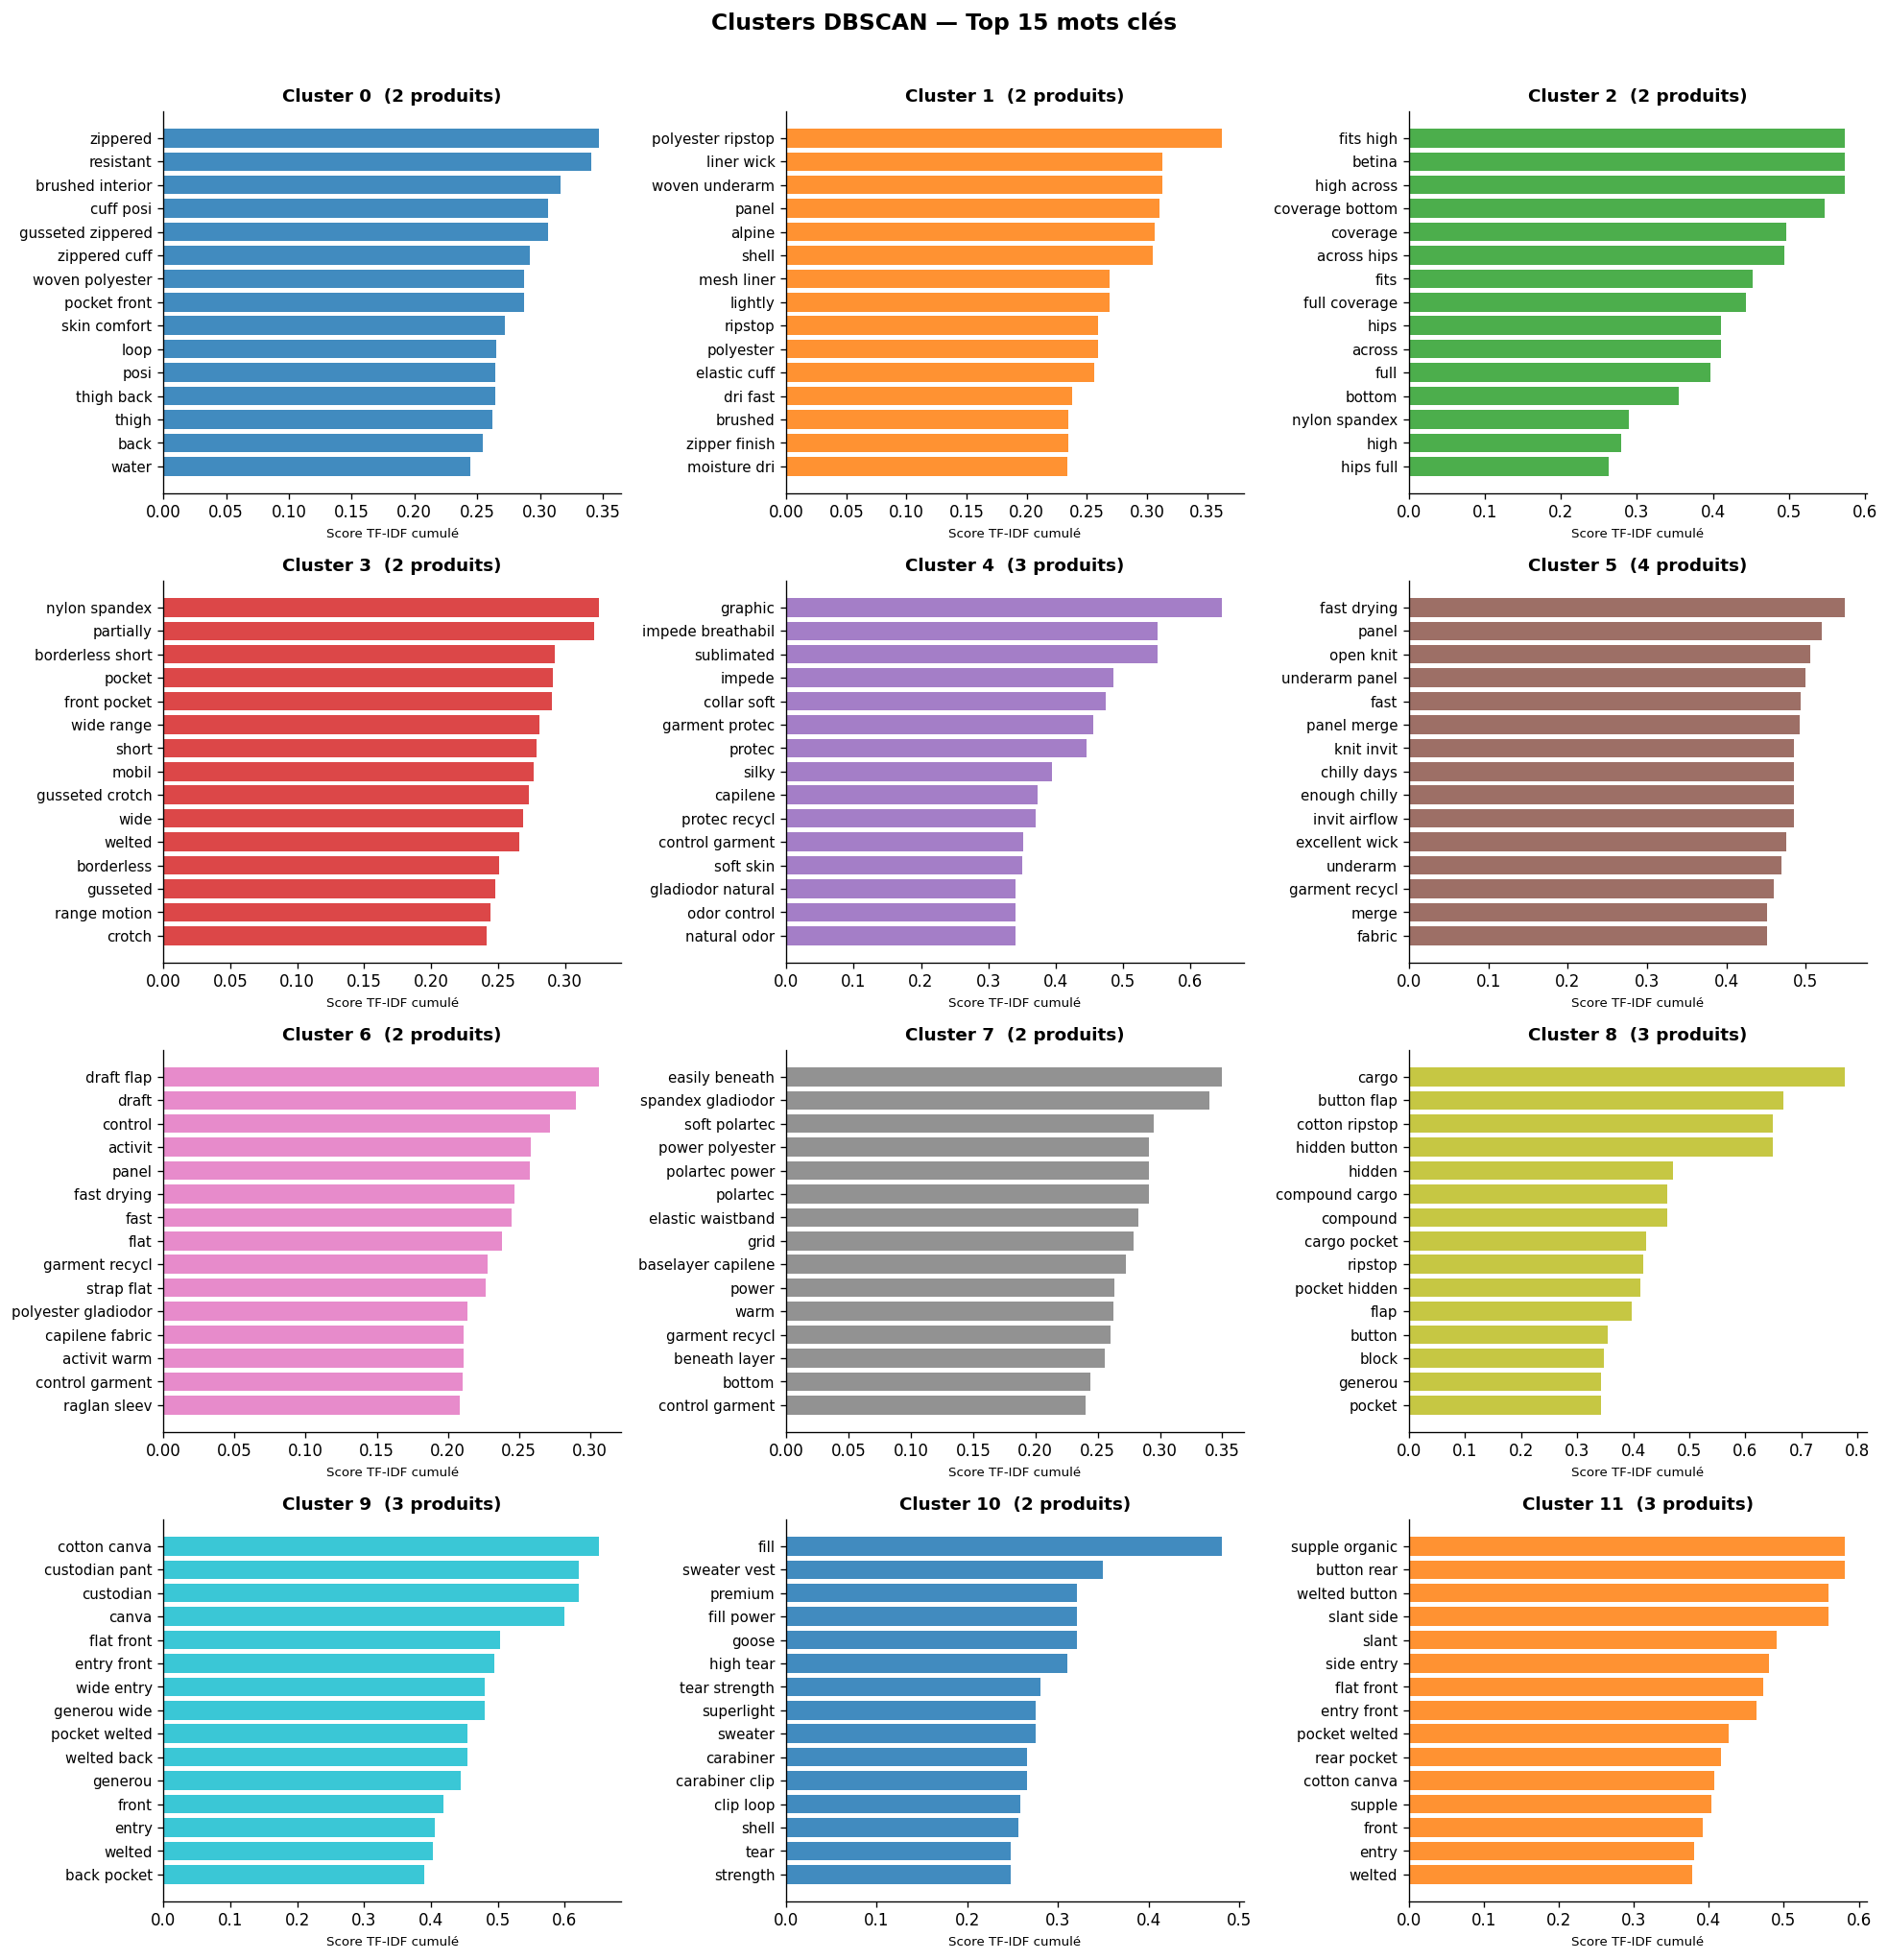

In [41]:
def get_top_words(cluster_id, n=15):
    """Retourne les n termes les plus représentatifs d'un cluster."""
    mask = df['cluster'] == cluster_id
    scores = np.asarray(tfidf_matrix[mask.values].sum(axis=0)).flatten()
    top_idx = scores.argsort()[::-1][:n]
    return [(feature_names[i], scores[i]) for i in top_idx]

def plot_clusters(cluster_ids, title="Clusters DBSCAN — Mots clés"):
    n = len(cluster_ids)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.5, rows * 4.2))
    axes = np.array(axes).flatten()
    palette = list(mcolors.TABLEAU_COLORS.values())

    for idx, cid in enumerate(cluster_ids):
        top = get_top_words(cid)
        if not top:
            continue
        words, scores = zip(*top)
        ax = axes[idx]
        ax.barh(range(len(words)), scores, color=palette[idx % len(palette)], alpha=0.85)
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        n_docs = (df['cluster'] == cid).sum()
        ax.set_title(f"Cluster {cid}  ({n_docs} produits)", fontsize=11, fontweight='bold')
        ax.set_xlabel("Score TF-IDF cumulé", fontsize=8)
        ax.spines[['top','right']].set_visible(False)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Affichage des 12 premiers clusters valides
valid_clusters = sorted([c for c in df['cluster'].unique() if c != -1])
plot_clusters(valid_clusters[:12], "Clusters DBSCAN — Top 15 mots clés")

---
##  PARTIE 2 — Système de Recommandation

### Logique
> Si deux produits appartiennent au **même cluster**, leurs descriptions sont proches  
> → ils sont considérés **similaires** → on peut se recommander l'un l'autre.

Pour affiner, parmi les produits du même cluster on **trie par similarité cosinus**  
afin de retourner les **5 plus proches** du produit cible.

```
Utilisateur regarde produit X
        │
        ▼
Quel est le cluster de X ?
        │
    ┌───┴───┐
cluster C    outlier (-1)
    │            │
candidats    tout le catalogue
du cluster C
        │
        ▼
Calculer cosine_similarity(X, candidats)
        │
        ▼
Top 5 des plus similaires → afficher
```

In [42]:
def find_similar_items(item_id, n=5):
    """
    Retourne les n produits les plus similaires à item_id.
    
    Paramètres
    ----------
    item_id : int  — identifiant produit (colonne 'id' du CSV)
    n       : int  — nombre de recommandations souhaitées
    
    Retourne
    --------
    DataFrame avec colonnes [id, similarity_score, apercu]
    """
    if item_id not in df['id'].values:
        print(f" Produit {item_id} introuvable.")
        return None

    idx        = df[df['id'] == item_id].index[0]
    cluster_id = df.loc[idx, 'cluster']
    vec        = tfidf_norm[idx]                # vecteur du produit cible

    # Candidats : même cluster OU tout le catalogue si outlier
    if cluster_id == -1:
        candidates = df[df['id'] != item_id]
    else:
        candidates = df[(df['cluster'] == cluster_id) & (df['id'] != item_id)]

    if candidates.empty:
        print(" Aucun voisin trouvé.")
        return None

    c_idx   = candidates.index.tolist()
    sims    = cosine_similarity(vec, tfidf_norm[c_idx]).flatten()
    top_idx = sims.argsort()[::-1][:n]

    result = df.loc[[c_idx[i] for i in top_idx], ['id', 'description']].copy()
    result['similarity_score'] = sims[top_idx]
    result['apercu'] = result['description'].apply(
        lambda x: re.sub(r'<[^>]+>', '', str(x))[:110] + "…"
    )
    return result[['id', 'similarity_score', 'apercu']].reset_index(drop=True)

###  Test sur quelques produits

In [43]:
# Afficher les recommandations pour 3 produits test
for test_id in [1, 4, 14]:
    row = df[df['id'] == test_id].iloc[0]
    titre = re.sub(r'<[^>]+>', '', row['description'])[:90]
    cluster = row['cluster']
    print(f"\n{'='*65}")
    print(f" Produit #{test_id} | Cluster {cluster}")
    print(f"   {titre}…")
    print(f"{'─'*65}")
    recs = find_similar_items(test_id)
    if recs is not None:
        for _, r in recs.iterrows():
            print(f"  ✦ #{int(r['id']):3d}  score={r['similarity_score']:.3f}  {r['apercu']}")


 Produit #1 | Cluster -1
   Active classic boxers - There's a reason why our boxers are a cult favorite - they keep th…
─────────────────────────────────────────────────────────────────
  ✦ # 19  score=0.417  Cap 1 boxer briefs - On bivy or belay, the form-fitting Capilene 1 Boxer Briefs stay dry and comfortable. Made…
  ✦ #494  score=0.379  Active boxer briefs - A no-fuss travel companion, these skivvies love sink and creek baths, and they dry in a …
  ✦ #495  score=0.296  Active briefs - These featherweight, quick-wicking briefs keep you comfortable and dry whether you travel by b…
  ✦ #365  score=0.276  Organic cotton boxers - After a day of getting maytagged in the water, slide on the Organic Cotton Boxers for …
  ✦ #  2  score=0.256  Active sport boxer briefs - Skinning up Glory requires enough movement without your boxers deciding to poach t…

 Produit #4 | Cluster 0
   Alpine guide pants - Skin in, climb ice, switch to rock, traverse a knife-edge ridge and b…
──────────────────

###  Interface utilisateur interactive

In [44]:
def interactive_recommendation():
    """
    Simule le champ de recherche du site web.
    L'utilisateur entre un ID produit → reçoit 5 suggestions.
    Tapez 'q' pour quitter.
    """
    print("\n" + "═"*60)
    print("  🏔️  THE NORTH FACE — Recommandation Produits")
    print("═"*60)
    print(f"  Catalogue : {len(df)} produits  |  IDs : {df['id'].min()}–{df['id'].max()}")
    print("  Tapez 'q' pour quitter\n")

    while True:
        user_input = input("Entrez un ID produit : ").strip()
        if user_input.lower() == 'q':
            print("Au revoir ! 👋")
            break
        try:
            item_id = int(user_input)
        except ValueError:
            print(" Veuillez entrer un nombre entier.\n")
            continue

        if item_id in df['id'].values:
            desc = re.sub(r'<[^>]+>', '', df[df['id']==item_id]['description'].values[0])[:130]
            print(f"\n {desc}…")

        recs = find_similar_items(item_id)
        if recs is not None:
            print("\n✨ Produits similaires :\n")
            for i, (_, r) in enumerate(recs.iterrows(), 1):
                print(f"  {i}. #{int(r['id'])}  ({r['similarity_score']:.1%})  {r['apercu']}")
        print()

# ▶ Décommenter pour lancer :
# interactive_recommendation()
print("  Exécutez interactive_recommendation() pour tester en live.")

  Exécutez interactive_recommendation() pour tester en live.


---
##  PARTIE 3 — Modélisation Thématique (LSA)

### Qu'est-ce que la LSA ?

La **Latent Semantic Analysis** utilise `TruncatedSVD` pour décomposer  
la matrice TF-IDF en **thèmes cachés** (latents).

$$X_{\text{docs×termes}} \approx U_{\text{docs×k}} \cdot \Sigma_{\text{k×k}} \cdot V^T_{\text{k×termes}}$$

- **U** : coordonnées des documents dans l'espace des thèmes  
- **Σ** : importance (variance expliquée) de chaque thème  
- **V** : association termes ↔ thèmes  

### Différence avec le clustering :

| | Clustering DBSCAN | LSA |
|---|---|---|
| Appartenance | 1 cluster par produit | Plusieurs thèmes par produit |
| Résultat | Groupes discrets | Scores continus par thème |
| Outliers | Oui (label -1) | Non |
| Interprétation | Plus directe | Plus nuancée |

>  Un produit "veste imperméable pour randonnée" peut scorer fort sur  
> *Thème Imperméabilité* ET *Thème Outdoor* simultanément.

In [45]:
N_TOPICS = 15

svd = TruncatedSVD(n_components=N_TOPICS, random_state=42, n_iter=10)
topic_matrix = svd.fit_transform(tfidf_matrix)

# DataFrame nommé comme demandé dans le projet
topic_encoded_df = pd.DataFrame(
    topic_matrix,
    columns=[f"topic_{i}" for i in range(N_TOPICS)]
)
topic_encoded_df['id'] = df['id'].values

print(f"Forme de topic_encoded_df : {topic_encoded_df.shape}")
print(f"Variance expliquée totale : {svd.explained_variance_ratio_.sum():.2%}")
print()
topic_encoded_df.head()

Forme de topic_encoded_df : (500, 16)
Variance expliquée totale : 25.02%



,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,id
0,0.156181,0.176309,0.207821,0.049017,-0.185902,-0.087871,0.015759,-0.055751,-0.018806,-0.030239,-0.038125,0.013006,0.028878,0.021671,0.015634,1
1,0.152881,0.153344,0.078492,0.051651,-0.046418,-0.137244,-0.001972,0.077179,0.007986,0.007803,-0.120589,0.062179,0.021604,-0.013681,0.074877,2
2,0.144932,0.170461,0.092300,0.005164,-0.038905,-0.066154,-0.003838,0.153955,0.069631,-0.013589,-0.123942,0.092280,-0.004219,-0.016874,0.098675,3
3,0.201529,0.299497,-0.074806,-0.130084,0.037626,-0.034079,-0.002006,-0.030154,-0.044145,0.122831,-0.071154,-0.099584,0.074820,0.075192,-0.032280,4
4,0.209070,0.314618,-0.043155,-0.202974,-0.019799,0.035207,-0.000440,0.051128,0.031417,0.214954,-0.104482,-0.074819,-0.109682,-0.145277,-0.052150,5


###  Variance expliquée par thème

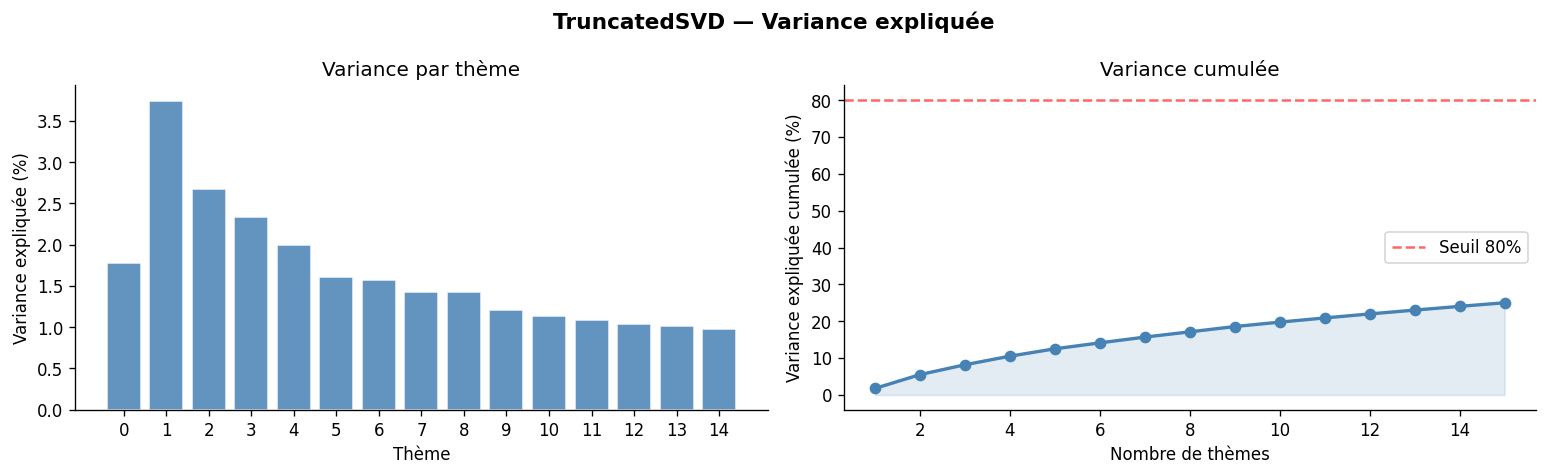

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Graphique 1 : variance par thème
ax1 = axes[0]
variances = svd.explained_variance_ratio_ * 100
ax1.bar(range(N_TOPICS), variances, color='steelblue', alpha=0.85, edgecolor='white')
ax1.set_xlabel("Thème")
ax1.set_ylabel("Variance expliquée (%)")
ax1.set_title("Variance par thème")
ax1.set_xticks(range(N_TOPICS))
ax1.spines[['top','right']].set_visible(False)

# Graphique 2 : variance cumulée
ax2 = axes[1]
cumvar = np.cumsum(variances)
ax2.plot(range(1, N_TOPICS+1), cumvar, 'o-', color='steelblue', linewidth=2)
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.6, label='Seuil 80%')
ax2.fill_between(range(1, N_TOPICS+1), cumvar, alpha=0.15, color='steelblue')
ax2.set_xlabel("Nombre de thèmes")
ax2.set_ylabel("Variance expliquée cumulée (%)")
ax2.set_title("Variance cumulée")
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.suptitle("TruncatedSVD — Variance expliquée", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  Thème dominant par produit

In [47]:
# Thème dominant = thème avec le score absolu le plus élevé
df['dominant_topic'] = np.abs(topic_matrix).argmax(axis=1)

print("Répartition des produits par thème dominant :")
print(df['dominant_topic'].value_counts().sort_index().rename('nb_produits').to_frame())

Répartition des produits par thème dominant :
                nb_produits
dominant_topic             
0                       110
1                       123
2                        33
3                        52
4                        16
5                        15
6                         8
7                        39
8                        37
9                        15
10                        4
11                       22
12                        6
13                        8
14                       12


###  Visualisation — Mots clés des thèmes LSA

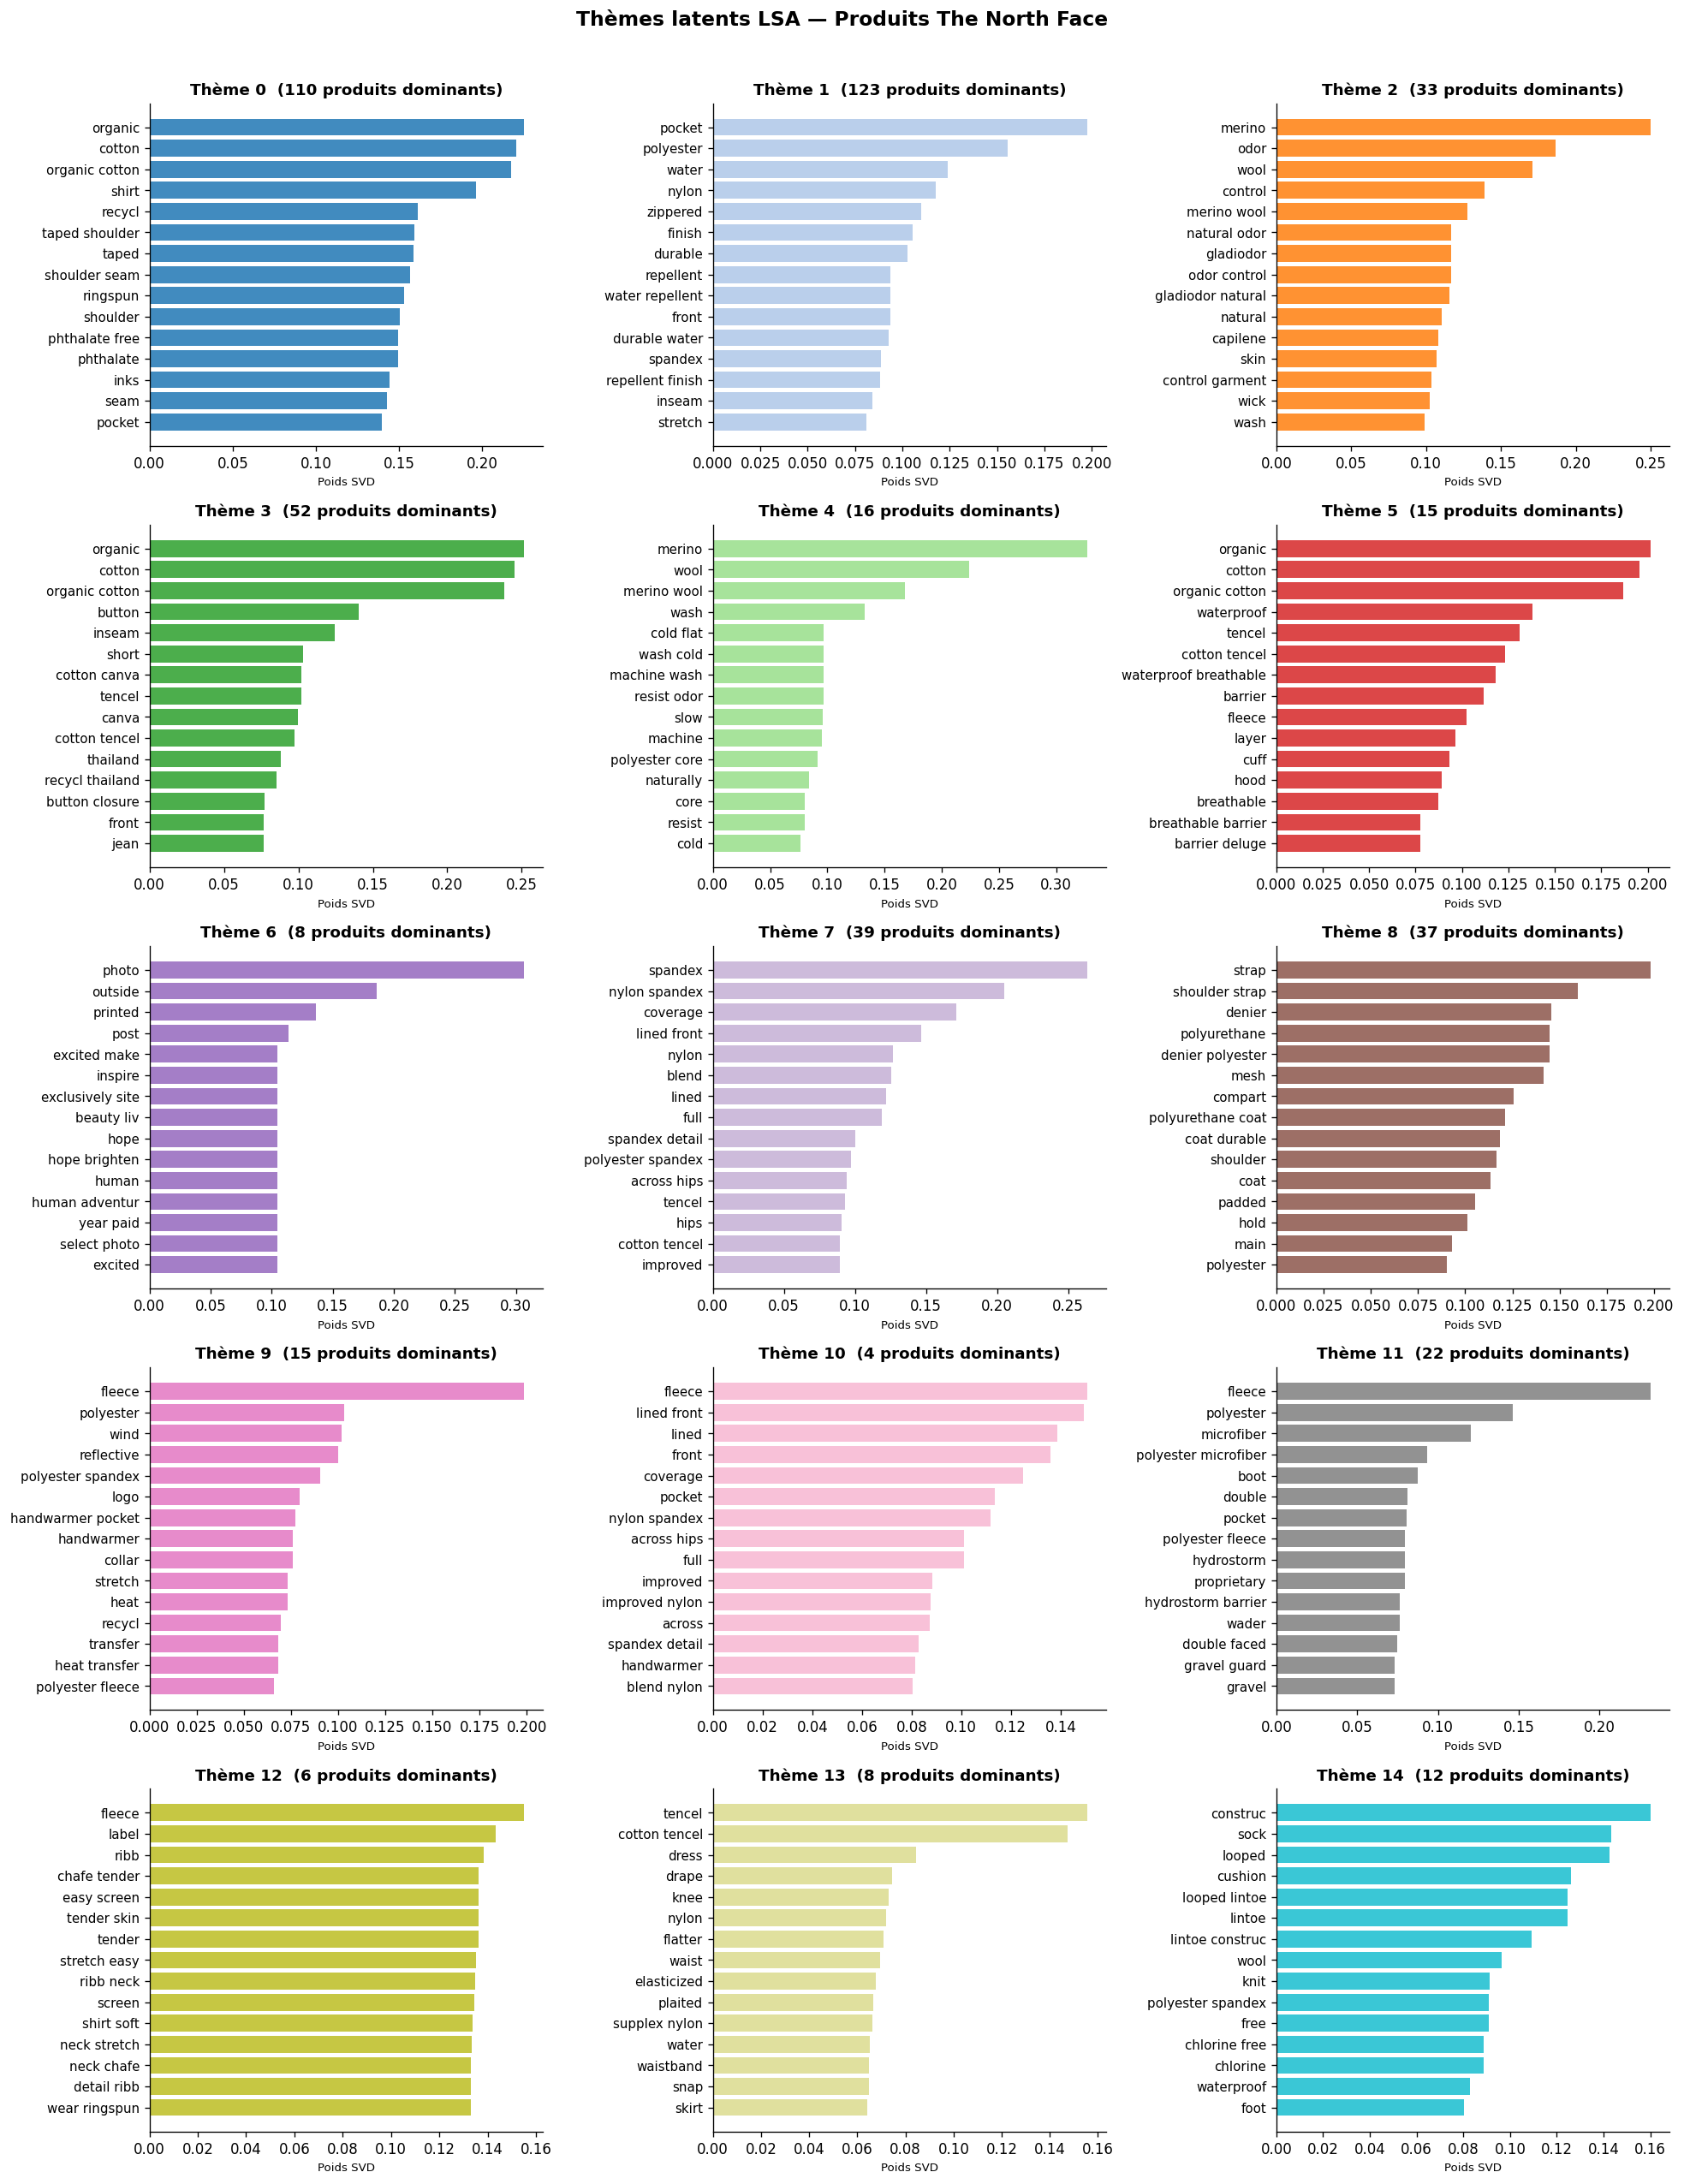

In [48]:
def get_top_words_topic(topic_id, n=15):
    """
    Retourne les n mots les plus associés à un thème LSA.
    Les composantes de svd.components_ donnent le poids de chaque
    terme dans chaque thème — un poids élevé = forte association.
    """
    component = svd.components_[topic_id]
    top_idx   = component.argsort()[::-1][:n]
    return [(feature_names[i], component[i]) for i in top_idx]

def plot_topics(topic_ids, title="Thèmes LSA — Mots clés"):
    n = len(topic_ids)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.5, rows * 4.2))
    axes = np.array(axes).flatten()
    cmap = plt.colormaps.get_cmap('tab20')

    for idx, tid in enumerate(topic_ids):
        top  = get_top_words_topic(tid)
        words, scores = zip(*top)
        ax = axes[idx]
        ax.barh(range(len(words)), scores,
                color=cmap(tid / N_TOPICS), alpha=0.85)
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        n_docs = (df['dominant_topic'] == tid).sum()
        ax.set_title(f"Thème {tid}  ({n_docs} produits dominants)",
                     fontsize=11, fontweight='bold')
        ax.set_xlabel("Poids SVD", fontsize=8)
        ax.spines[['top','right']].set_visible(False)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_topics(list(range(N_TOPICS)), "Thèmes latents LSA — Produits The North Face")

###  Résumé des thèmes — Interprétation

In [49]:
print(f"{'Thème':<8} {'Nb produits':<14} {'Mots clés principaux'}")
print("─" * 75)
for tid in range(N_TOPICS):
    top   = get_top_words_topic(tid, n=7)
    words = ", ".join([w for w, _ in top])
    n_doc = (df['dominant_topic'] == tid).sum()
    print(f"  {tid:<6} {n_doc:<14} {words}")

Thème    Nb produits    Mots clés principaux
───────────────────────────────────────────────────────────────────────────
  0      110            organic, cotton, organic cotton, shirt, recycl, taped shoulder, taped
  1      123            pocket, polyester, water, nylon, zippered, finish, durable
  2      33             merino, odor, wool, control, merino wool, natural odor, gladiodor
  3      52             organic, cotton, organic cotton, button, inseam, short, cotton canva
  4      16             merino, wool, merino wool, wash, cold flat, wash cold, machine wash
  5      15             organic, cotton, organic cotton, waterproof, tencel, cotton tencel, waterproof breathable
  6      8              photo, outside, printed, post, excited make, inspire, exclusively site
  7      39             spandex, nylon spandex, coverage, lined front, nylon, blend, lined
  8      37             strap, shoulder strap, denier, polyurethane, denier polyester, mesh, compart
  9      15             fl

---
##  Synthèse finale — DataFrame enrichi

On enrichit le DataFrame initial avec les résultats des deux analyses.

In [50]:
df_final = df[['id', 'cluster', 'dominant_topic', 'clean_description']].copy()
df_final['top_topic_score'] = np.abs(topic_matrix).max(axis=1).round(4)

print(f"Produits analysés  : {len(df_final)}")
print(f"Clusters DBSCAN    : {df_final['cluster'].nunique() - 1} clusters + outliers")
print(f"Thèmes LSA         : {N_TOPICS}")
print()
df_final.head(10)

Produits analysés  : 500
Clusters DBSCAN    : 81 clusters + outliers
Thèmes LSA         : 15



,id,cluster,dominant_topic,clean_description,top_topic_score
0,1,-1,2,active classic boxer reason boxer cult favorit...,0.2078
1,2,-1,1,active sport boxer brief skinn glory requir en...,0.1533
2,3,-1,1,active sport brief superbreathable brief minim...,0.1705
3,4,0,1,alpine guide pant skin climb switch rock trave...,0.2995
4,5,1,1,alpine wind high ridg steep anyth alpine jacke...,0.3146
5,6,-1,1,ascensionist technical soft shell full mountai...,0.2600
6,7,-1,8,atom multitasker cloud nine atom play part cou...,0.4411
7,8,2,7,print banded betina full coverage bottom betin...,0.3886
8,9,-1,9,baby micro luxe cardigan micro luxe heavenly s...,0.1715
9,10,-1,1,baby bucket goes ris horizon stay raindrop sta...,0.1568


In [51]:
# Export CSV
df_final.to_csv('produits_enrichis.csv', index=False)
print(" Fichier 'produits_enrichis.csv' sauvegardé")

 Fichier 'produits_enrichis.csv' sauvegardé


---
##  Conclusion

| Partie | Méthode | Résultat |
|---|---|---|
| Groupes similaires | TF-IDF + DBSCAN | ~80 clusters, 61% outliers (catalogue très varié) |
| Recommandation | Similarité cosinus intra-cluster | Top 5 produits similaires par ID |
| Thèmes latents | TF-IDF + TruncatedSVD (LSA) | 15 thèmes : mérino, imperméable, sacs, polaires… |

###  Améliorations possibles
- Tester **K-Means** ou **HDBSCAN** pour le clustering
- Utiliser des **embeddings pré-entraînés** (sentence-transformers) pour une meilleure représentation sémantique
- Augmenter `n_components` dans LSA pour capturer plus de variance
- Ajouter les **noms des produits** en plus des descriptions